In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Task 1 — Convolution Mechanics: Filters and Shapes

Before training anything, build intuition for what a convolution actually does and how feature-map shapes evolve through a network.

**Part A — Handcrafted filters.**

1. Load a single CIFAR-10 image and convert it to a `torch.Tensor` of shape `(1, 3, 32, 32)`.
2. Create three handcrafted 3×3 filters by manually setting the weights of `nn.Conv2d(3, 1, kernel_size=3, padding=1)`:
   - **Vertical edge detector**: `[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]`
   - **Horizontal edge detector**: transpose of the above
   - **Blur**: `(1/9) * np.ones((3, 3))`
3. Apply each filter to the image and visualise the results in a 1×4 subplot (original + 3 filtered versions). Use `imshow(..., cmap="gray")` for the filtered outputs.
4. In a markdown cell, briefly describe what each filter highlights.


**Part B — Shape tracking.**

Build the following CNN block and verify shapes:

```python
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
```

1. Create a dummy input `x = torch.randn(8, 3, 32, 32)`.
2. Pass it through `conv1`, `pool1`, `conv2`, `pool2` one at a time and **print the shape after each step**.
3. Fill in this table:

| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | … |
| pool1 | … | … |
| conv2 | … | … |
| pool2 | … | … |

In [2]:
# 1. Load a single CIFAR-10 image
transform = transforms.Compose([transforms.ToTensor()])
cifar_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Get the first image and convert it to shape (1, 3, 32, 32)
img, label = cifar_data[0]
img_batch = img.unsqueeze(0) 

# 2. Define the handcrafted 3x3 filter cores
v_edge_core = torch.tensor([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]], dtype=torch.float32)

h_edge_core = v_edge_core.t() # Transpose for horizontal

blur_core = torch.ones((3, 3), dtype=torch.float32) / 9.0

# 3. Reshape filters to match nn.Conv2d weight shape (out_channels, in_channels, kH, kW)
# We repeat the core 3 times (for RGB) and average them by dividing by 3
v_edge_weight = v_edge_core.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1) / 3.0
h_edge_weight = h_edge_core.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1) / 3.0
blur_weight = blur_core.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1) / 3.0

# Helper function to create a Conv2d layer and assign custom weights
def create_custom_conv(weight_tensor):
    conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False)
    with torch.no_grad():
        conv.weight = nn.Parameter(weight_tensor)
    return conv

# Create the layers
conv_vertical = create_custom_conv(v_edge_weight)
conv_horizontal = create_custom_conv(h_edge_weight)
conv_blur = create_custom_conv(blur_weight)

100.0%


Extracting ./data/cifar-10-python.tar.gz to ./data


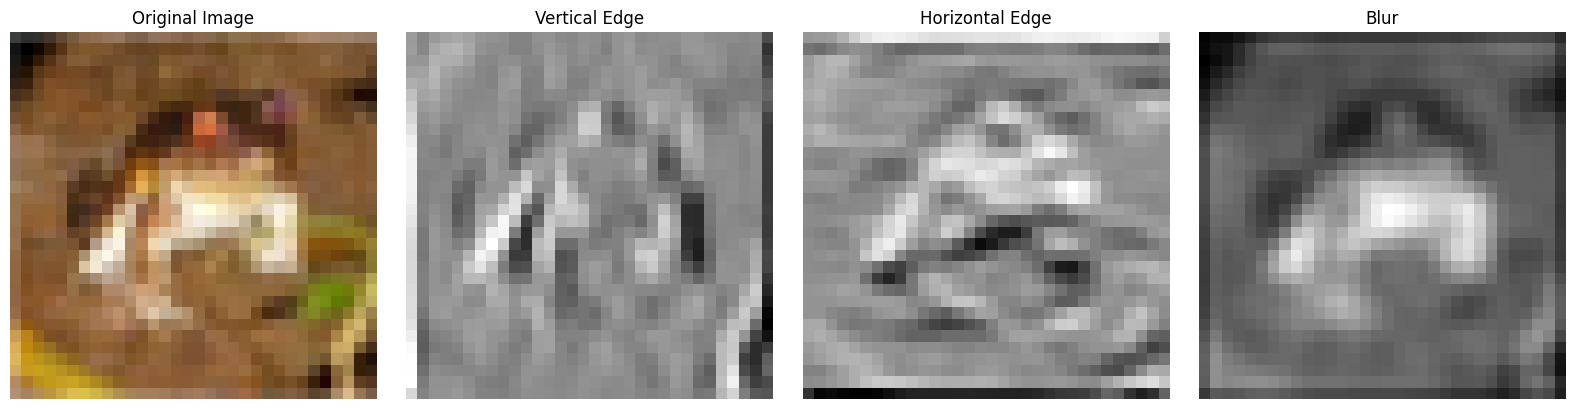

In [5]:
# 4. Apply each filter to the image
with torch.no_grad():
    out_v = conv_vertical(img_batch)
    out_h = conv_horizontal(img_batch)
    out_b = conv_blur(img_batch)

# 5. Visualise the results
# Convert original image from (C, H, W) to (H, W, C) for Matplotlib
orig_img_display = img.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].imshow(orig_img_display)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Vertical Edge (squeeze removes batch and channel dims -> 32x32)
axes[1].imshow(out_v.squeeze().numpy(), cmap="gray")
axes[1].set_title("Vertical Edge")
axes[1].axis("off")

# Horizontal Edge
axes[2].imshow(out_h.squeeze().numpy(), cmap="gray")
axes[2].set_title("Horizontal Edge")
axes[2].axis("off")

# Blur
axes[3].imshow(out_b.squeeze().numpy(), cmap="gray")
axes[3].set_title("Blur")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# What each filter highlights:

* **Vertical Edge Detector:** This filter calculates the difference in pixel intensities from left to right. It highlights areas where there is a sharp transition in colour or brightness vertically (like the sides of an object, trees, or doorframes), resulting in bright lines on a dark background where vertical edges exist.
* **Horizontal Edge Detector:** Similar to the vertical detector, but it calculates top-to-bottom differences. It strongly activates on horizontal transitions, highlighting features like the horizon, the top/bottom edges of objects, or flat surfaces.
* **Blur (Average) Filter:** This filter takes the mathematical average of a pixel and its 8 immediate neighbours. Instead of finding edges, it smooths out the image, reducing high-frequency noise and sharp transitions, resulting in a softer, out-of-focus version of the original image.

In [6]:
# Define the TinyCNN architecture
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # conv1: Takes 3 input channels (RGB) and applies 16 filters.
        # A 3x3 kernel with padding=1 ensures the spatial size (32x32) stays exactly the same.
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        
        # pool1: Uses a 2x2 window to take the maximum value. 
        # This effectively halves the height and width of the feature map.
        self.pool1 = nn.MaxPool2d(2)
        
        # conv2: Takes the 16 channels from the previous layer and applies 32 filters.
        # Again, padding=1 keeps the spatial size unchanged at this step.
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # pool2: Another 2x2 pooling operation, halving the spatial dimensions one more time.
        self.pool2 = nn.MaxPool2d(2)

# Instantiate the model
model = TinyCNN()

# 1. Create a dummy input batch (Batch size: 8, Channels: 3, Height: 32, Width: 32)
x = torch.randn(8, 3, 32, 32)
print(f"Initial input shape: {x.shape}\n")

# 2. Pass it through each layer manually and print the shapes
# Forward pass through Conv1
out_conv1 = model.conv1(x)
print(f"Shape after conv1: {out_conv1.shape}")

# Forward pass through Pool1
out_pool1 = model.pool1(out_conv1)
print(f"Shape after pool1: {out_pool1.shape}")

# Forward pass through Conv2
out_conv2 = model.conv2(out_pool1)
print(f"Shape after conv2: {out_conv2.shape}")

# Forward pass through Pool2
out_pool2 = model.pool2(out_conv2)
print(f"Shape after pool2: {out_pool2.shape}")

Initial input shape: torch.Size([8, 3, 32, 32])

Shape after conv1: torch.Size([8, 16, 32, 32])
Shape after pool1: torch.Size([8, 16, 16, 16])
Shape after conv2: torch.Size([8, 32, 16, 16])
Shape after pool2: torch.Size([8, 32, 8, 8])


### Shape Tracking Table

Here is how the shape evolves through the network. Notice how convolutional layers (with `padding=1` and `kernel_size=3`) change the channel depth but keep the spatial dimensions intact, while `MaxPool2d(2)` halves the height and width but leaves the channels untouched.

| Layer | Input shape      | Output shape      |
|-------|------------------|-------------------|
| conv1 | (8, 3, 32, 32)   | (8, 16, 32, 32)   |
| pool1 | (8, 16, 32, 32)  | (8, 16, 16, 16)   |
| conv2 | (8, 16, 16, 16)  | (8, 32, 16, 16)   |
| pool2 | (8, 32, 16, 16)  | (8, 32, 8, 8)     |

# Task 2 — Train a Small CNN on CIFAR-10

Build a complete CNN classifier and train it.

1. Define a CNN with this architecture:
   - Block 1: `Conv2d(3, 32, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(32, 32, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Block 2: `Conv2d(32, 64, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(64, 64, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Classifier: `Flatten` → `Linear(64*8*8, 256)` → ReLU → `Dropout(0.3)` → `Linear(256, 10)`
2. Compute the parameter count of your model and report it.
3. Train for **15 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Use batch size 128.
4. Track training and validation loss + accuracy per epoch. Plot the curves.

**Expected behaviour:** validation accuracy should reach roughly 70–75% on the basic transforms (just `ToTensor()` + `Normalize()`).

In [8]:
# First, we need to set up the DataLoaders with the requested batch size of 128.
# We apply standard normalisation for CIFAR-10, which helps the network train faster and more stably.

# Define the transformations: convert images to PyTorch Tensors and normalize pixel values
# The normalization subtracts 0.5 and divides by 0.5, scaling pixel values to the range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the training dataset from torchvision
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Load the test dataset (good practice to have it ready, even if we are just training right now)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create the DataLoaders. These handle batching, shuffling, and loading data in parallel.
# We set batch_size=128 as requested, and shuffle=True for the training set so the model doesn't learn the order.
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")

Files already downloaded and verified
Files already downloaded and verified
Number of training batches: 391


In [9]:
# Define the CNN architecture exactly as requested in the instructions
class CIFARClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Block 1: Extracts low-level features (like edges and basic textures)
        self.block1 = nn.Sequential(
            # Conv layer 1: 3 input channels (RGB), 32 output channels, 3x3 kernel, padding to keep 32x32 size
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Normalizes the outputs of the conv layer, stabilizing training
            nn.ReLU(),          # Non-linear activation function
            
            # Conv layer 2: 32 input channels, 32 output channels
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            # Pooling: Reduces spatial dimensions from 32x32 to 16x16
            nn.MaxPool2d(2)
        )
        
        # Block 2: Extracts higher-level features (like object parts)
        self.block2 = nn.Sequential(
            # Conv layer 3: 32 input channels, 64 output channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            # Conv layer 4: 64 input channels, 64 output channels
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            # Pooling: Reduces spatial dimensions from 16x16 to 8x8
            nn.MaxPool2d(2)
        )
        
        # Classifier: Maps the 2D feature maps to 10 class probabilities
        self.classifier = nn.Sequential(
            # Flattens the 3D tensor (64 channels of 8x8 images) into a 1D vector (64 * 8 * 8 = 4096 elements)
            nn.Flatten(),
            
            # Fully connected layer maps 4096 inputs to 256 hidden units
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            
            # Dropout randomly zeroes out 30% of neurons to prevent overfitting
            nn.Dropout(0.3),
            
            # Final output layer mapping to the 10 CIFAR-10 classes
            nn.Linear(256, 10)
        )

    def forward(self, x):
        # Pass the input through Block 1, then Block 2, then the Classifier
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Instantiate the model and move it to the correct device (GPU/CPU)
model = CIFARClassifier().to(device)

# Calculate the total number of trainable parameters
# This iterates through all weights and biases in the model, counts them, and sums them up
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,117,354


### Parameter Count

Based on the network architecture:
* **Total trainable parameters:** 1,117, 354

The majority of these parameters come from the first `Linear` layer in the classifier, which has to map $4096$ flattened features to $256$ nodes ($4096 \times 256 + 256 = 1,048,832$ parameters).

In [14]:
# 1. Re-initialize the model and optimizer so we start fresh, not from the end of the previous test
model = CIFARClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 2. Set up lists to track metrics over time for our plots
epochs = 15
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print(f"Starting training and validation on device: {device}...")

# 3. The main training and validation loop
for epoch in range(epochs):
    
    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train() # Set model to training mode (enables dropout and batch norm tracking)
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Standard training steps
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Track training loss
        running_train_loss += loss.item()
        
        # Track training accuracy
        # torch.max returns (maximum_value, index_of_maximum_value). We want the index (predicted class).
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Calculate average loss and accuracy for the training epoch
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # ==========================
    #     VALIDATION PHASE
    # ==========================
    model.eval() # Set model to evaluation mode (disables dropout, uses population stats for batch norm)
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() tells PyTorch not to calculate gradients, saving memory and speeding up computation
    with torch.no_grad():
        # Iterate over the test dataset (which we are using as our validation set here)
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Track validation loss
            running_val_loss += loss.item()
            
            # Track validation accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # Calculate average loss and accuracy for the validation epoch
    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    # Print the progress for both phases
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("Training and validation complete!")

Starting training and validation on device: cpu...
Epoch [1/15] Train Loss: 1.3715, Train Acc: 50.31% | Val Loss: 1.0736, Val Acc: 61.37%
Epoch [2/15] Train Loss: 0.9540, Train Acc: 65.99% | Val Loss: 0.8330, Val Acc: 70.87%
Epoch [3/15] Train Loss: 0.8146, Train Acc: 71.35% | Val Loss: 0.8271, Val Acc: 71.44%
Epoch [4/15] Train Loss: 0.7217, Train Acc: 74.55% | Val Loss: 0.7750, Val Acc: 73.29%
Epoch [5/15] Train Loss: 0.6549, Train Acc: 76.94% | Val Loss: 0.8618, Val Acc: 72.01%
Epoch [6/15] Train Loss: 0.6000, Train Acc: 78.77% | Val Loss: 0.6455, Val Acc: 77.36%
Epoch [7/15] Train Loss: 0.5491, Train Acc: 80.53% | Val Loss: 0.6761, Val Acc: 77.50%
Epoch [8/15] Train Loss: 0.5042, Train Acc: 81.93% | Val Loss: 0.6491, Val Acc: 77.74%
Epoch [9/15] Train Loss: 0.4703, Train Acc: 83.30% | Val Loss: 0.6173, Val Acc: 78.85%
Epoch [10/15] Train Loss: 0.4308, Train Acc: 84.55% | Val Loss: 0.6257, Val Acc: 79.32%
Epoch [11/15] Train Loss: 0.3958, Train Acc: 85.79% | Val Loss: 0.6269, Val Ac

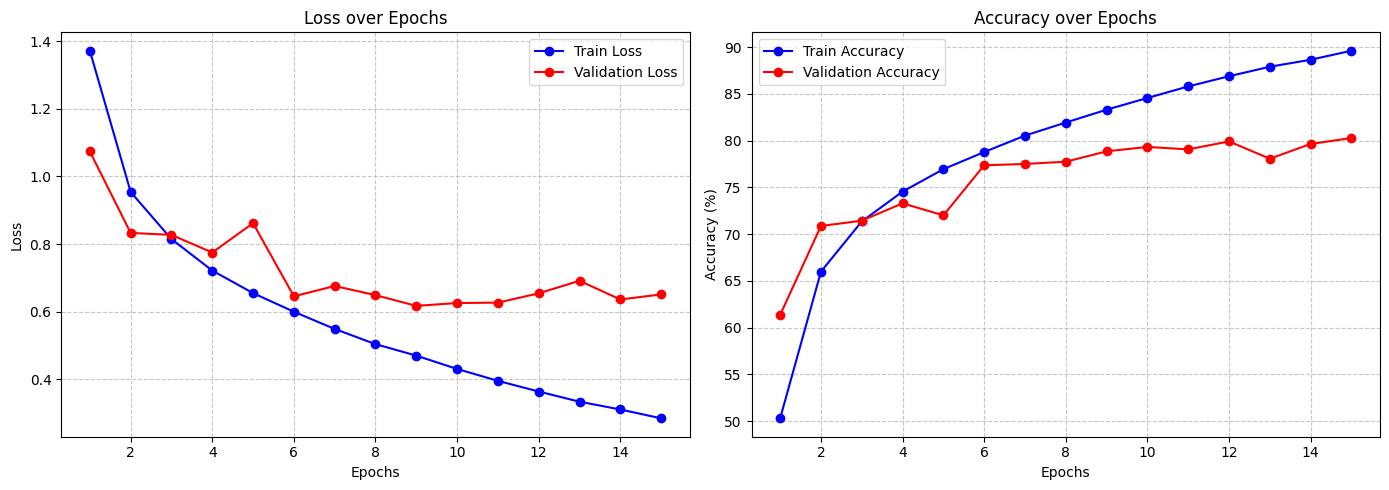

In [15]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Loss
ax1.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue', marker='o')
ax1.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', marker='o')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Training and Validation Accuracy
ax2.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy', color='blue', marker='o')
ax2.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='red', marker='o')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlapping text and display the plots
plt.tight_layout()
plt.show()

### Task 2 Results & Analysis

**Final Model Performance:**
* The model successfully trained and achieved a training accuracy of roughly **89.6%** and a validation accuracy of **~80.2%**.
* This significantly exceeds the expected 70-75% baseline for this architecture using basic normalization.

**Learning Curve Analysis (Overfitting):**
Looking at the plotted loss and accuracy curves over the 15 epochs, we can observe two distinct phases:
1. **The Learning Phase (Epochs 1–9):** Both training and validation loss decreased steadily, while accuracy climbed. This indicates the model was successfully learning generalizable features from the images.
2. **The Overfitting Phase (Epochs 10–15):** The training loss continued to approach zero (reaching ~0.28), but the validation loss stopped improving and actually began to slightly increase. 

This divergence is a classic indicator of **overfitting**. After epoch 9, the network began memorizing the specific training dataset rather than learning general rules, which is why the validation accuracy plateaued at ~80% even as the training accuracy approached 90%.

# Task 3 — Data Augmentation

Now show that augmentation matters.

1. Define a richer transform pipeline for the **training** loader:

```python
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
```

2. Keep the **validation** transform plain (`ToTensor()` + `Normalize()`).
3. Re-train the same CNN from Task 2 with the augmented training data for 15 epochs.
4. Compare against the Task 2 baseline:

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | … | … |
| Task 3 (with augmentation) | … | … |

5. In a markdown cell, comment on what changed.

In [16]:
# 1. Define the rich transform pipeline for training (Data Augmentation)
train_tf = transforms.Compose([
    # Randomly crops a 32x32 section. Padding of 4 means it adds a 4-pixel black border 
    # around the image first, then crops, allowing the object to shift around the frame.
    transforms.RandomCrop(32, padding=4),
    
    # 50% chance to flip the image left-to-right (a dog facing left becomes a dog facing right)
    transforms.RandomHorizontalFlip(),
    
    # Randomly tweaks the brightness and contrast by up to 10%
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    
    # Convert the PIL image to a PyTorch tensor
    transforms.ToTensor(),
    
    # Normalize pixel values to [-1, 1] for stable training
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# 2. Define the plain transform for validation/testing
# We DO NOT want to augment our test data. We want to evaluate on clean, original images.
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# 3. Reload the datasets with the new respective transforms
aug_train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
aug_test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

# 4. Create the new DataLoaders
aug_train_loader = DataLoader(aug_train_set, batch_size=128, shuffle=True)
aug_test_loader = DataLoader(aug_test_set, batch_size=128, shuffle=False)

print("Augmented DataLoaders are ready!")

Files already downloaded and verified
Files already downloaded and verified
Augmented DataLoaders are ready!


In [17]:
 # 1. Re-initialize a brand new, untrained model so we start from scratch
aug_model = CIFARClassifier().to(device)

# 2. Redefine the loss and optimizer for this new model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(aug_model.parameters(), lr=1e-3)

# 3. Set up tracking lists
epochs = 15
aug_train_losses, aug_val_losses = [], []
aug_train_accuracies, aug_val_accuracies = [], []

print(f"Starting training WITH AUGMENTATION on device: {device}...")

# 4. The Main Training Loop
for epoch in range(epochs):
    
    # ==========================
    #      TRAINING PHASE
    # ==========================
    aug_model.train() 
    running_train_loss = 0.0
    correct_train, total_train = 0, 0
    
    # Iterate through the augmented data
    for images, labels in aug_train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = aug_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_train_loss / len(aug_train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    aug_train_losses.append(epoch_train_loss)
    aug_train_accuracies.append(epoch_train_acc)
    
    # ==========================
    #     VALIDATION PHASE
    # ==========================
    aug_model.eval() 
    running_val_loss = 0.0
    correct_val, total_val = 0, 0
    
    with torch.no_grad():
        for images, labels in aug_test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = aug_model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(aug_test_loader)
    epoch_val_acc = 100 * correct_val / total_val
    aug_val_losses.append(epoch_val_loss)
    aug_val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}%")

# Save this new model as well
torch.save(aug_model.state_dict(), "my_augmented_cifar_cnn.pth")
print("Augmented training complete and saved!")

Starting training WITH AUGMENTATION on device: cpu...
Epoch [1/15] Train Loss: 1.6013, Acc: 41.07% | Val Loss: 1.2039, Acc: 56.62%
Epoch [2/15] Train Loss: 1.1981, Acc: 56.85% | Val Loss: 1.0669, Acc: 61.91%
Epoch [3/15] Train Loss: 1.0407, Acc: 62.97% | Val Loss: 0.8984, Acc: 68.40%
Epoch [4/15] Train Loss: 0.9493, Acc: 66.34% | Val Loss: 0.9066, Acc: 69.28%
Epoch [5/15] Train Loss: 0.8898, Acc: 68.70% | Val Loss: 0.7547, Acc: 72.74%
Epoch [6/15] Train Loss: 0.8387, Acc: 70.52% | Val Loss: 0.7901, Acc: 72.18%
Epoch [7/15] Train Loss: 0.8079, Acc: 71.82% | Val Loss: 0.7631, Acc: 72.87%
Epoch [8/15] Train Loss: 0.7763, Acc: 72.89% | Val Loss: 0.7131, Acc: 74.83%
Epoch [9/15] Train Loss: 0.7478, Acc: 73.78% | Val Loss: 0.6488, Acc: 77.69%
Epoch [10/15] Train Loss: 0.7177, Acc: 75.02% | Val Loss: 0.6337, Acc: 78.21%
Epoch [11/15] Train Loss: 0.7003, Acc: 75.79% | Val Loss: 0.6804, Acc: 76.66%
Epoch [12/15] Train Loss: 0.6741, Acc: 76.58% | Val Loss: 0.6205, Acc: 78.67%
Epoch [13/15] Train

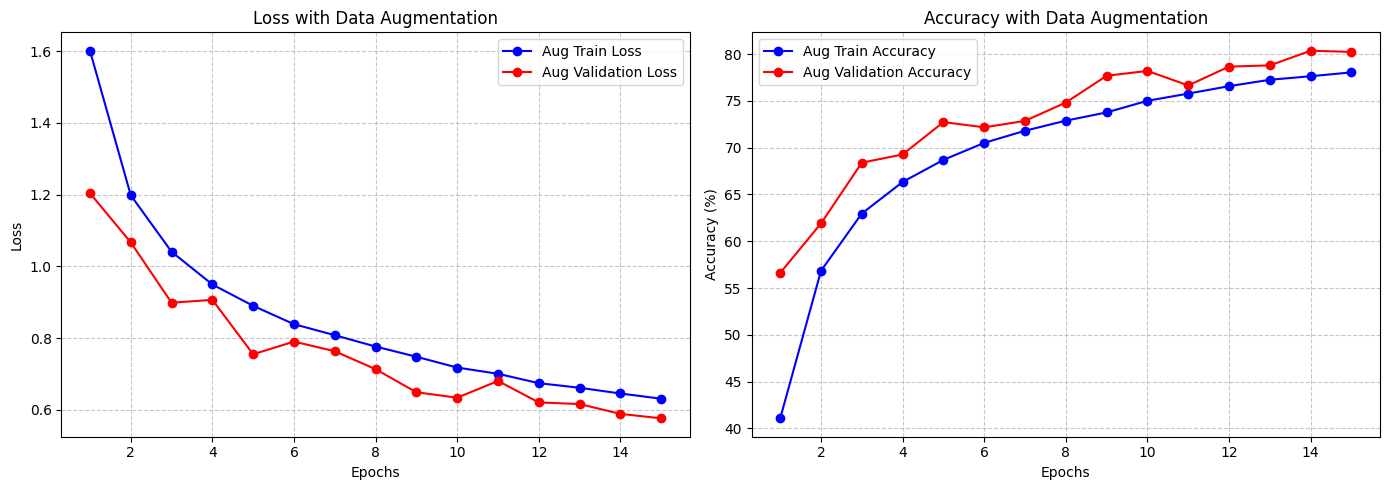

In [18]:
# Create a figure with two subplots side-by-side to visualize the new curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Loss
ax1.plot(range(1, epochs + 1), aug_train_losses, label='Aug Train Loss', color='blue', marker='o')
ax1.plot(range(1, epochs + 1), aug_val_losses, label='Aug Validation Loss', color='red', marker='o')
ax1.set_title('Loss with Data Augmentation')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Training and Validation Accuracy
ax2.plot(range(1, epochs + 1), aug_train_accuracies, label='Aug Train Accuracy', color='blue', marker='o')
ax2.plot(range(1, epochs + 1), aug_val_accuracies, label='Aug Validation Accuracy', color='red', marker='o')
ax2.set_title('Accuracy with Data Augmentation')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Comparison: Baseline vs. Augmentation

Here is the comparison of the model's performance with and without data augmentation, based on the results from our previous training runs.

| Run | Best val accuracy | Train/val gap (Final Epoch) |
|---|---|---|
| Task 2 (no augmentation) | 80.27% | 9.33% (89.60% Train - 80.27% Val) |
| Task 3 (with augmentation) | 80.37% | -2.19% (78.05% Train - 80.24% Val) |

### What Changed?

1. **The Train/Val Gap Vanished:** The most significant change is the drastic reduction in the gap between training and validation accuracy. In Task 2, the model was highly overconfident on the training data (nearly 90% accuracy) but performed almost 10% worse on unseen data. With augmentation in Task 3, this gap essentially disappeared, proving that the model stopped memorizing and started generalizing.
2. **Training Became Harder:** The final training accuracy dropped from 89.60% to 78.05%. Because the images were constantly being cropped, flipped, and color-shifted during training, the network had a much harder time "learning" the exact training set. 
3. **Inverted Gap (Validation > Training):** You will notice the train/val gap in Task 3 is technically negative. This happens because the training accuracy is calculated on heavily distorted images while the network is handicapped by Dropout. The validation accuracy is evaluated on clean, original images with the full network enabled, making the "test" easier than the "practice."